### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import raw data

In [7]:
df=pd.read_csv("blinkit_data.csv")

### Sample data

In [10]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [12]:
df.tail()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


### Size of data

In [19]:
print("(Row, Column):",df.shape)

(Row, Column): (8523, 12)


### Field information

In [22]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

### Data Types

In [27]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

### Data Cleaning

In [32]:
for i in df.columns:
    print(f"{i}={df[i].unique()}")

Item Fat Content=['Regular' 'Low Fat' 'low fat' 'LF' 'reg']
Item Identifier=['FDX32' 'NCB42' 'FDR28' ... 'FDU60' 'NCX53' 'FDE52']
Item Type=['Fruits and Vegetables' 'Health and Hygiene' 'Frozen Foods' 'Canned'
 'Soft Drinks' 'Household' 'Snack Foods' 'Meat' 'Breads' 'Hard Drinks'
 'Others' 'Dairy' 'Breakfast' 'Baking Goods' 'Seafood' 'Starchy Foods']
Outlet Establishment Year=[2012 2022 2010 2000 2015 2020 2011 1998 2017]
Outlet Identifier=['OUT049' 'OUT018' 'OUT046' 'OUT013' 'OUT045' 'OUT017' 'OUT010' 'OUT027'
 'OUT035' 'OUT019']
Outlet Location Type=['Tier 1' 'Tier 3' 'Tier 2']
Outlet Size=['Medium' 'Small' 'High']
Outlet Type=['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']
Item Visibility=[0.1000135  0.00859605 0.02589649 ... 0.03470581 0.02757094 0.10771483]
Item Weight=[15.1   11.8   13.85  12.15  19.6    8.89  19.7   20.75     nan 18.85
 17.1   16.35  20.25  17.85  19.2   12.1    6.85  17.25  16.    13.35
  6.695 16.6    6.92   5.82  14.8   10.1    

In [34]:
df['Item Fat Content']=df['Item Fat Content'].replace({'reg':'Regular','LF':'Low Fat','low fat':'Low Fat'})

In [38]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


## Business Requirements

#### KPI's

In [117]:
#total sales
total_sales=df['Sales'].sum()
#avg sales
avg_sales=df['Sales'].mean()
#No. of items sold
items_sold=df['Sales'].count()
#avg ratings
avg_rating=df['Rating'].mean()
print(f"Total Sales: ${total_sales:,.0f}")
print(f"Average Sales: ${avg_sales:,.2f}")
print(f"Items Sold: ${items_sold:,.0f}")
print(f"Average Rating: ${avg_rating:,.1f}")

Total Sales: $1,201,681
Average Sales: $140.99
Items Sold: $8,523
Average Rating: $4.0


#### Charts

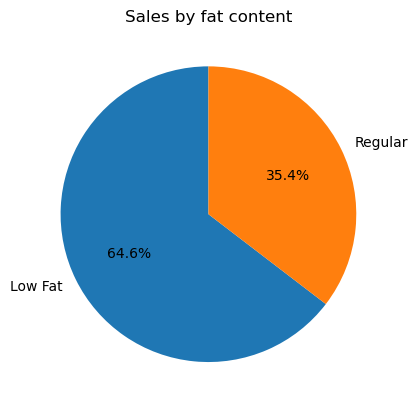

In [48]:
#total sales by fat content
sales_by_fat=df.groupby('Item Fat Content')['Sales'].sum()
plt.pie(sales_by_fat,labels=sales_by_fat.index,autopct='%.1f%%',startangle=90)
plt.title("Sales by fat content")
plt.show()

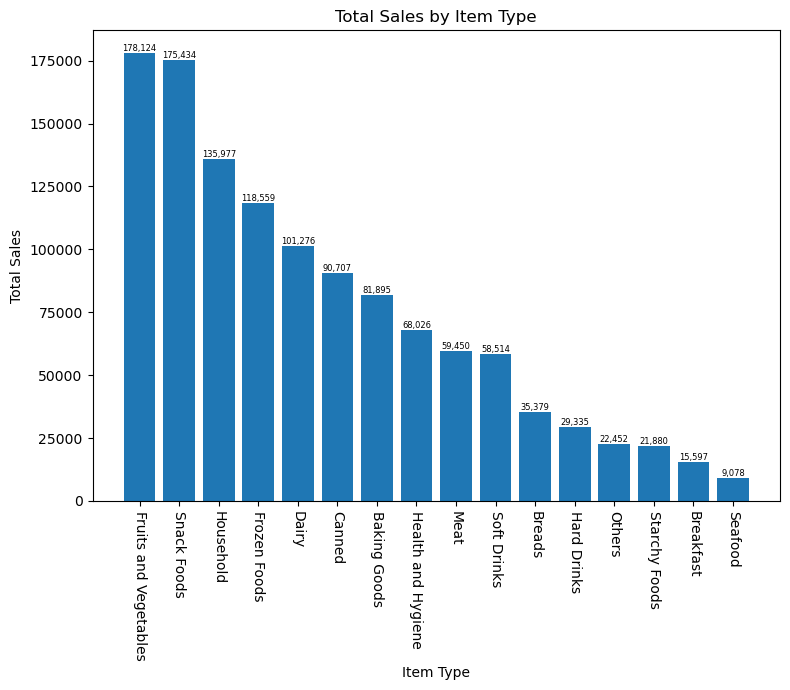

In [109]:
#total sales by item
plt.figure(figsize=(8,7))
sales_by_type=df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)
plt.bar(sales_by_type.index,sales_by_type.values)
plt.xlabel('Item Type')
plt.ylabel('Total Sales')
plt.title("Total Sales by Item Type")
plt.xticks(rotation=-90)
for i,value in enumerate(sales_by_type.values):
    plt.text(i,value,f'{value:,.0f}',ha='center',va='bottom',fontsize=6)
plt.tight_layout()
plt.show()

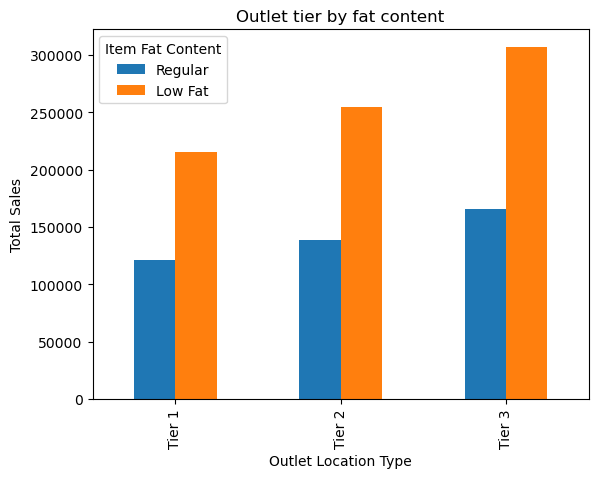

In [185]:
#fat content by outlet for total sales
grouped=df.groupby(['Outlet Location Type','Item Fat Content'])['Sales'].sum().unstack()
grouped=grouped[['Regular','Low Fat']]
ax=grouped.plot(kind='bar')
plt.ylabel('Total Sales')
plt.title("Outlet tier by fat content")
plt.show()



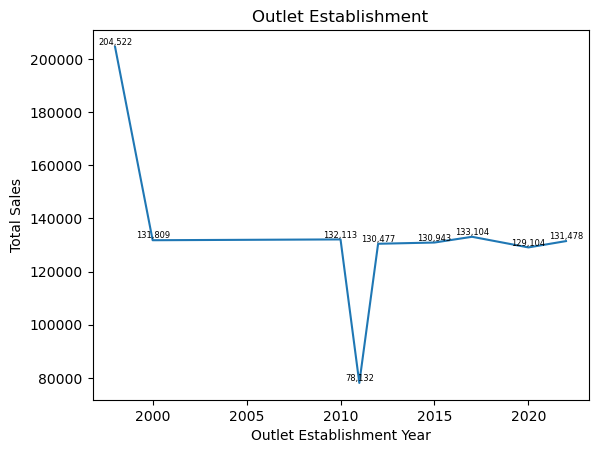

In [147]:
#Total sales by outlet eshlablishment
sales_by_outlet=df.groupby("Outlet Establishment Year")['Sales'].sum().sort_index()
plt.plot(sales_by_outlet.index,sales_by_outlet.values)
plt.xlabel("Outlet Establishment Year")
plt.ylabel("Total Sales")
plt.title("Outlet Establishment")
for i,value in zip(sales_by_outlet.index,sales_by_outlet.values):
    plt.text(i,value,f'{value:,.0f}',ha='center',va='bottom',fontsize=6)
plt.show()

In [141]:
sales_by_outlet

Outlet Establishment Year
1998    204522.2570
2000    131809.0156
2010    132113.3698
2011     78131.5646
2012    130476.8598
2015    130942.7782
2017    133103.9070
2020    129103.9564
2022    131477.7724
Name: Sales, dtype: float64

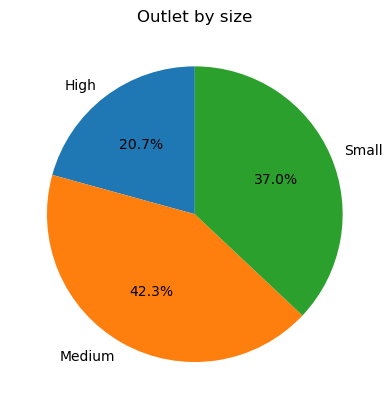

In [153]:
#Sales by outlet size
sales_by_outlet=df.groupby('Outlet Size')['Sales'].sum()
plt.pie(sales_by_outlet.values,labels=sales_by_outlet.index,autopct='%0.1f%%',startangle=90)
plt.title("Outlet by size")
plt.show()

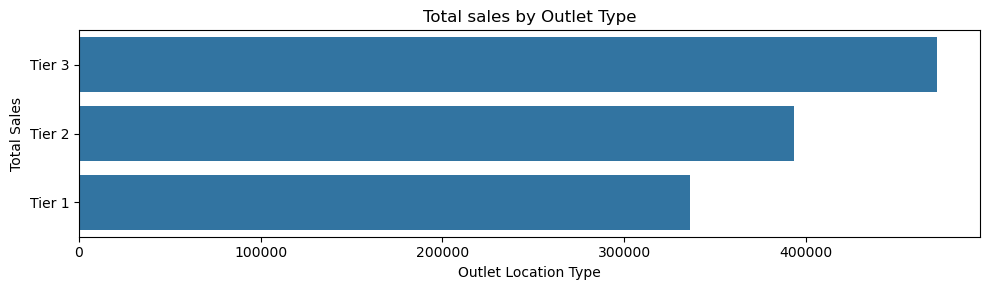

In [183]:
#sales by outlet location 
plt.figure(figsize=(10,3))
sales_by_location=df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
sales_by_location=sales_by_location.sort_values('Sales',ascending=False)
sns.barplot(y='Outlet Location Type',x='Sales',data=sales_by_location)
plt.xlabel("Outlet Location Type")
plt.ylabel("Total Sales")
plt.title("Total sales by Outlet Type")
plt.tight_layout()
plt.show()